# Dataset analysis — one 2×2 figure per record

A fresh pass over every dataset in `dataloader`. For each record we produce the
standard four-panel figure from `visualizer.figure`:

| panel | content |
|---|---|
| **(a)** | the raw record, as it arrived |
| **(b)** | amplitude spectrum, with the dominant periods marked |
| **(c)** | divergence curve, with the fitted window highlighted |
| **(d)** | the record on a Lyapunov-time axis, gridded every e-folding |

Everything is recomputed here — nothing is read from `outputs/` or the committed
figures. Run top to bottom.

> **Estimator provenance.** `lyapunov.estimate` uses the **ensemble** estimator
> when a record carries independent realizations (chaotic tier only) and falls
> back to single-trajectory **Rosenstein** otherwise. Those are not
> interchangeable: check the `method` column in the summary before quoting any
> number. Section 2 runs the chaotic tier first precisely so the estimator's
> error against published λ₁ is visible before any real record is read.


## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import analysis
import compare
import dataloader as dl
import lyapunov as lyap

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- estimator cost knob -----------------------------------------------------
# Rosenstein's neighbour search is a full O(N^2) distance matrix, so the long
# records dominate the runtime. MAX_N truncates before embedding (a prefix, so
# dt and therefore the exponent's units are unchanged).
#   5000 = lyapunov.py's own default;  2500 ~ 4x faster, used by the HQRC notebook.
MAX_N = 5000

SAVE_FIGURES = False        # True writes figures/<key>_analysis.png
PEAKS = 5                   # spectral lines to mark in panel (b)

print("datasets:", ", ".join(dl.load_all()))

datasets: lorenz63, vallieselnino, lorenz84, hadley, rikitake, nino34, nino12, tao, nyc, lax, potomac, potomac15, opsd, brest, cuxhaven, solar, load


## 2. Chaotic tier — what the estimator does where the answer is known

These five carry independent realizations *and* a published λ₁, so they are the
only rows where error is measurable. Read the `error` line in each report: it
bounds the method, not any individual real record below.

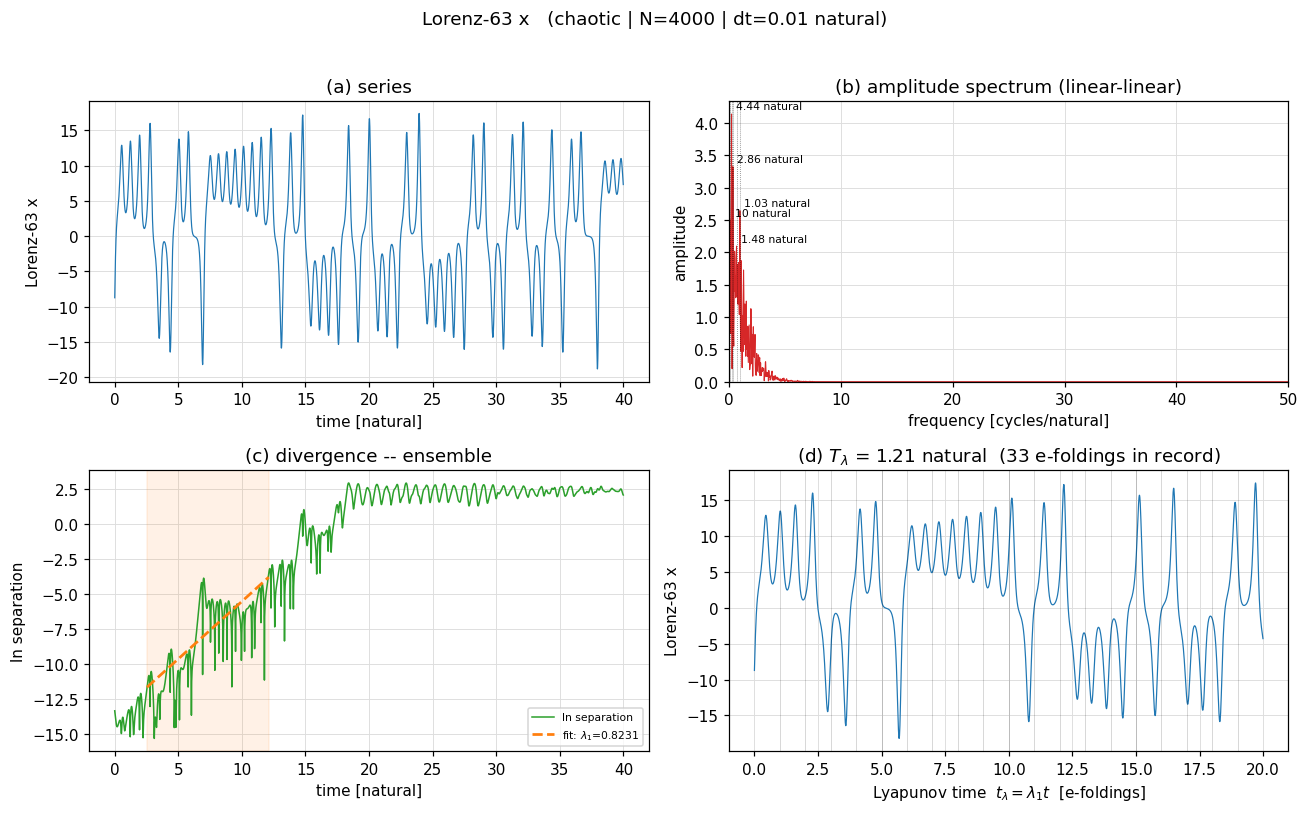


=== Lorenz-63 x  [chaotic]
  N = 4000   dt = 0.01 natural   span = 40 natural   R = 12
  lambda_1 = 0.8231 /natural   T_lambda = 1.21 natural   [ensemble, R=12]
    published lambda_1 = 0.9056, error -9.1%
  record length = 32.9 e-foldings
  dominant periods:
         4.444 natural   (f = 0.225 /natural,  amp = 4.141)
         2.857 natural   (f = 0.35 /natural,  amp = 3.326)
         1.026 natural   (f = 0.975 /natural,  amp = 2.645)
            10 natural   (f = 0.1 /natural,  amp = 2.5)
         1.481 natural   (f = 0.675 /natural,  amp = 2.097)


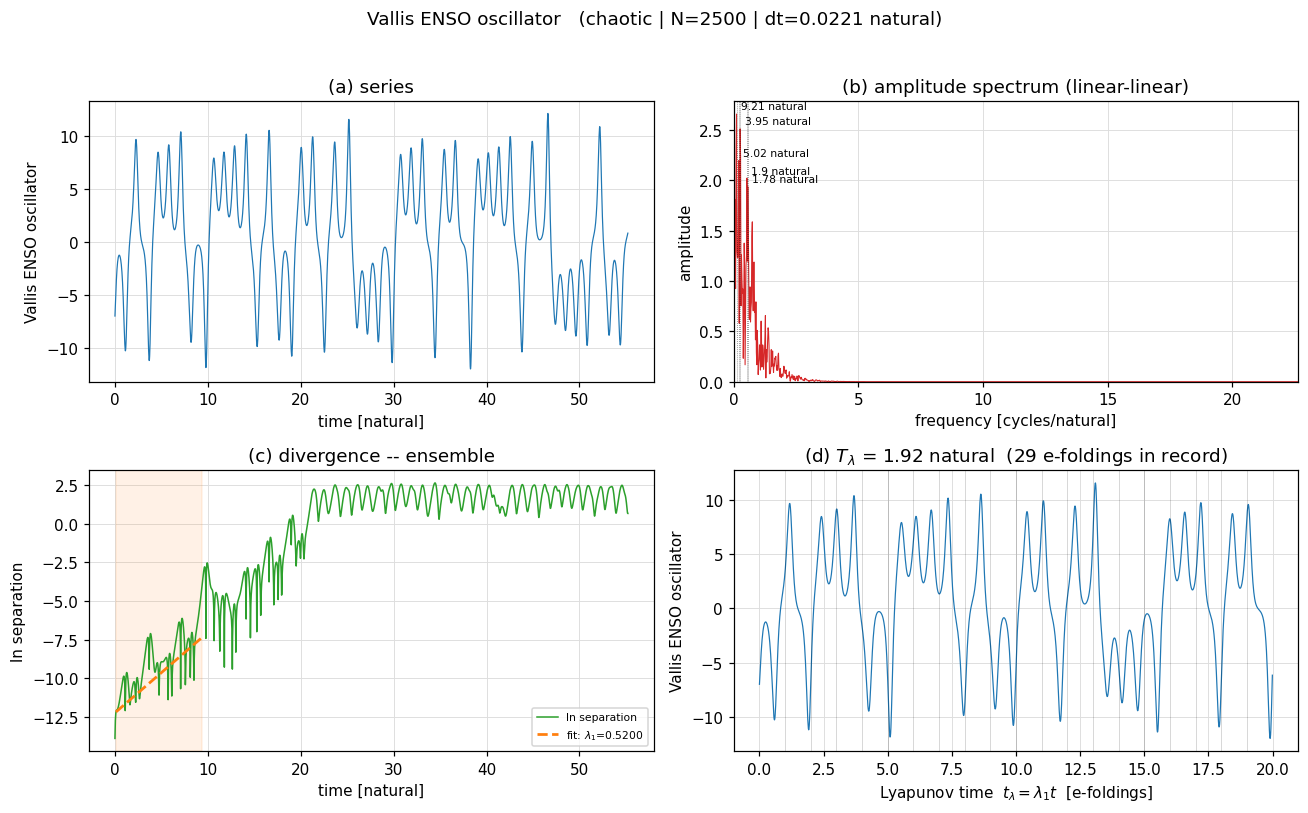


=== Vallis ENSO oscillator  [chaotic]
  N = 2500   dt = 0.0221 natural   span = 55.24 natural   R = 8
  lambda_1 = 0.5200 /natural   T_lambda = 1.92 natural   [ensemble, R=8]
    published lambda_1 = 0.5478, error -5.1%
  record length = 28.7 e-foldings
  dominant periods:
         9.207 natural   (f = 0.10862 /natural,  amp = 2.659)
         3.946 natural   (f = 0.25344 /natural,  amp = 2.512)
         5.022 natural   (f = 0.19913 /natural,  amp = 2.196)
         1.905 natural   (f = 0.52499 /natural,  amp = 2.022)
         1.782 natural   (f = 0.56119 /natural,  amp = 1.937)


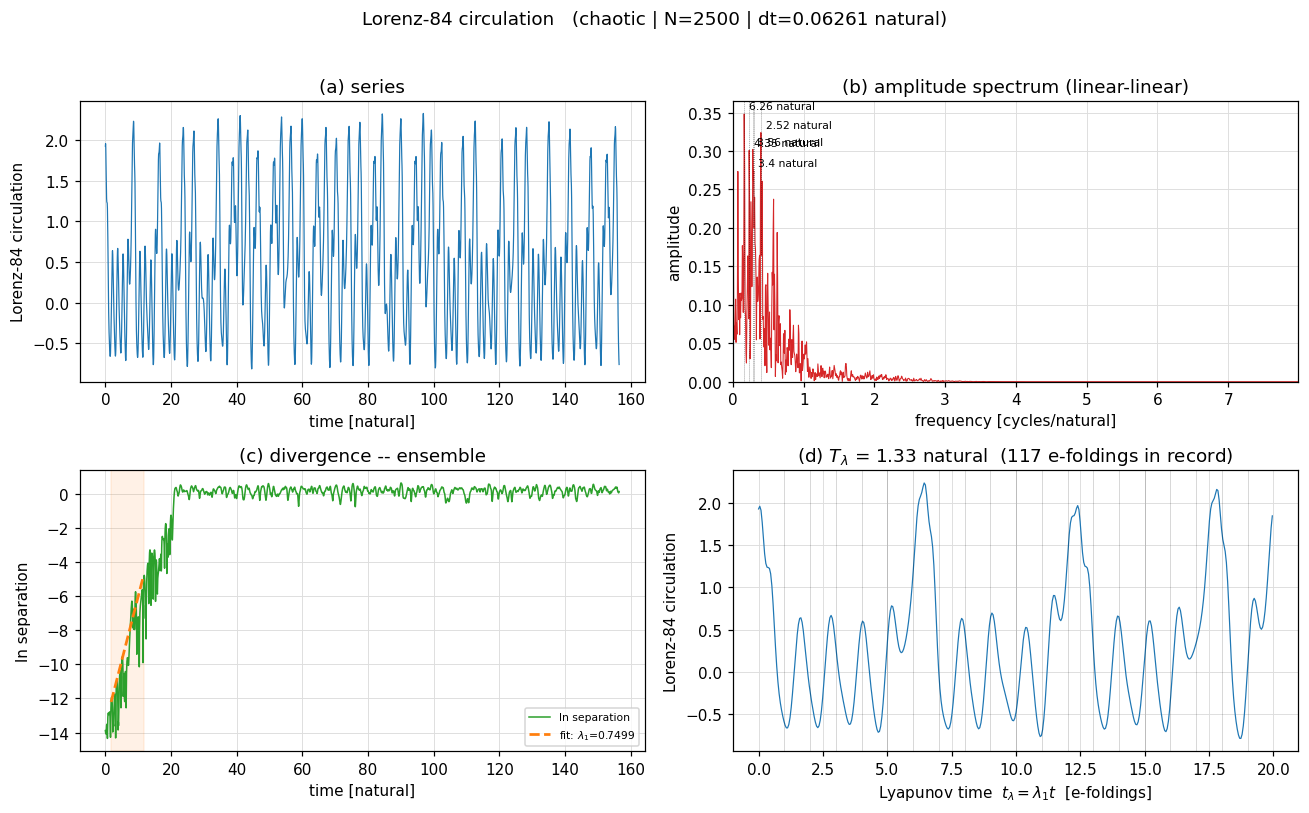


=== Lorenz-84 circulation  [chaotic]
  N = 2500   dt = 0.06261 natural   span = 156.5 natural   R = 8
  lambda_1 = 0.7499 /natural   T_lambda = 1.33 natural   [ensemble, R=8]
    published lambda_1 = 0.4615, error +62.5%
  record length = 117.4 e-foldings
  dominant periods:
         6.261 natural   (f = 0.15972 /natural,  amp = 0.348)
         2.525 natural   (f = 0.3961 /natural,  amp = 0.3239)
         3.557 natural   (f = 0.2811 /natural,  amp = 0.302)
         4.348 natural   (f = 0.22999 /natural,  amp = 0.3007)
         3.403 natural   (f = 0.29388 /natural,  amp = 0.2739)


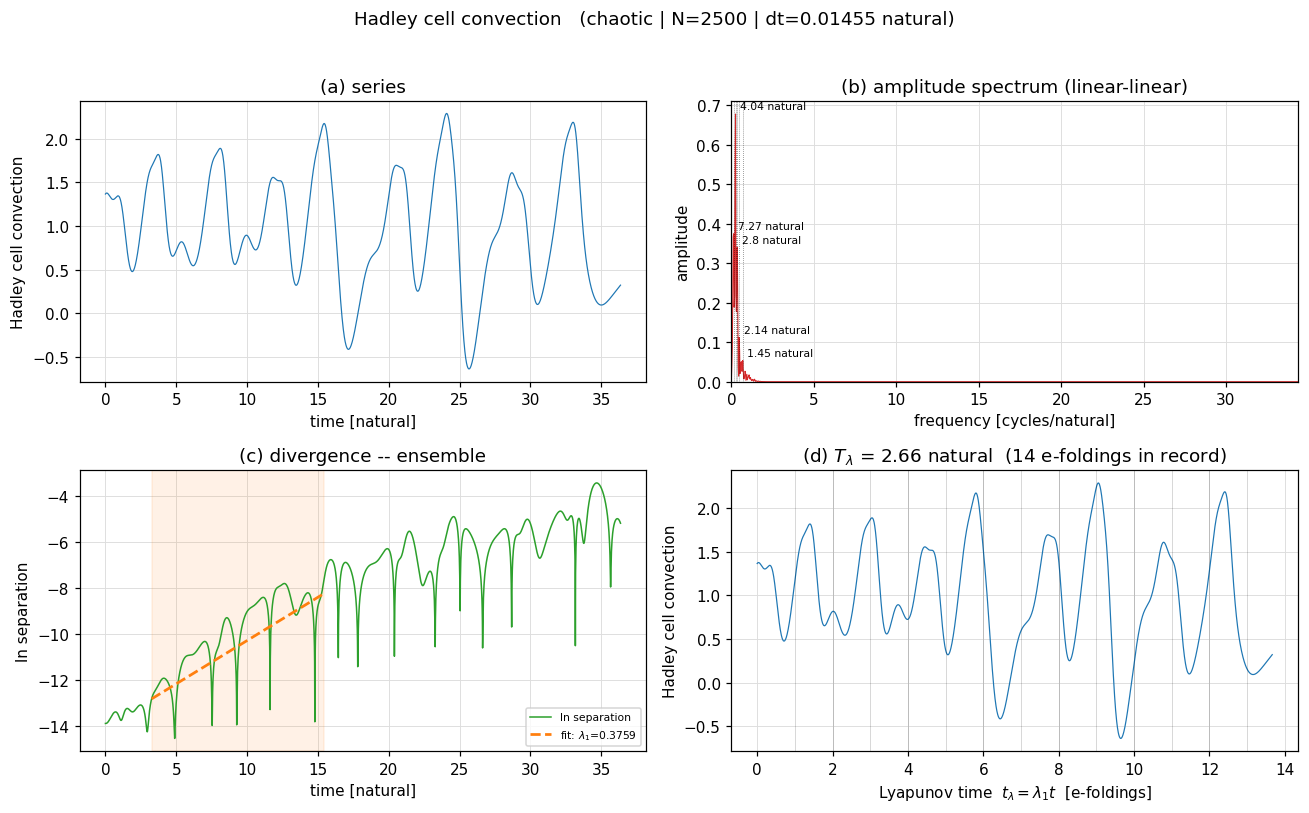


=== Hadley cell convection  [chaotic]
  N = 2500   dt = 0.01455 natural   span = 36.37 natural   R = 8
  lambda_1 = 0.3759 /natural   T_lambda = 2.66 natural   [ensemble, R=8]
    published lambda_1 = 0.2387, error +57.5%
  record length = 13.7 e-foldings
  dominant periods:
         4.041 natural   (f = 0.24748 /natural,  amp = 0.6771)
         7.273 natural   (f = 0.13749 /natural,  amp = 0.3743)
         2.797 natural   (f = 0.35747 /natural,  amp = 0.3402)
         2.139 natural   (f = 0.46746 /natural,  amp = 0.1116)
         1.455 natural   (f = 0.68744 /natural,  amp = 0.05363)


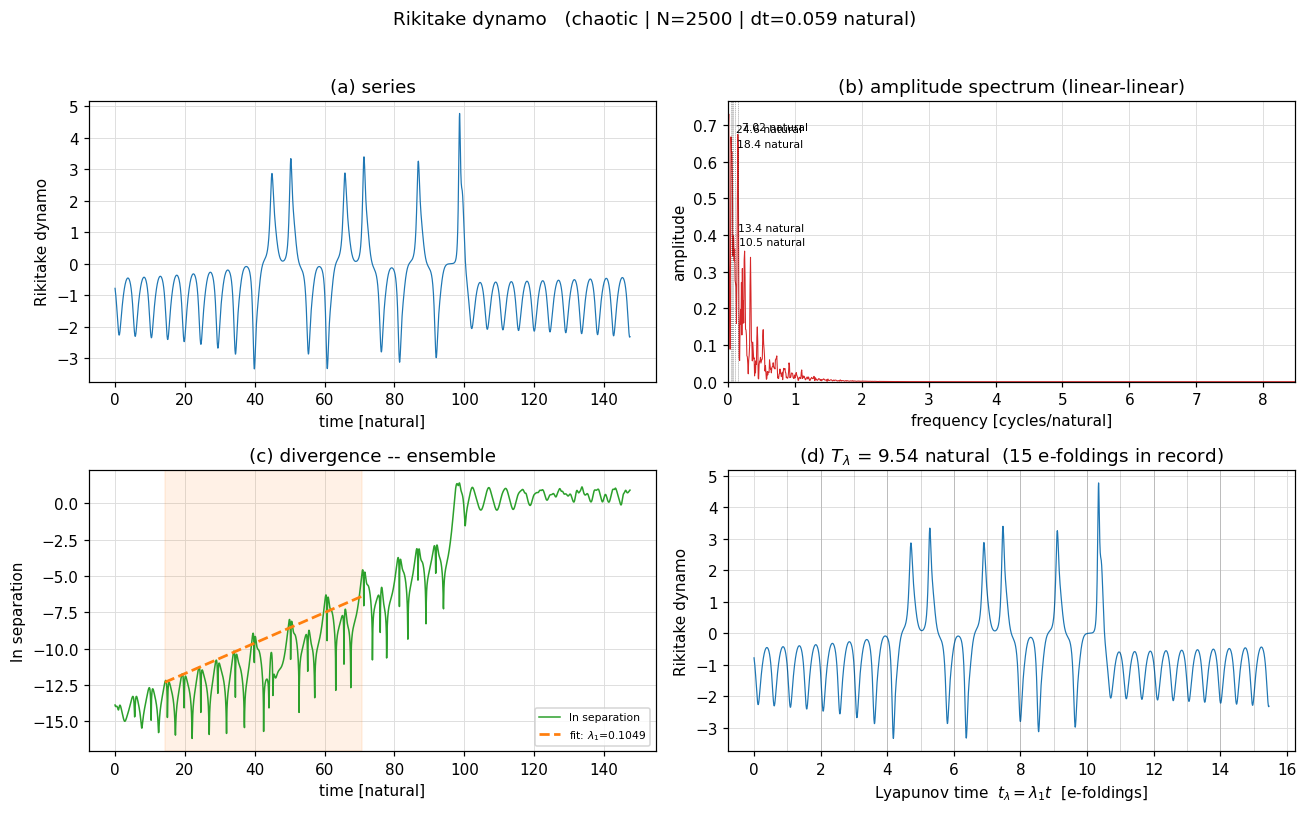


=== Rikitake dynamo  [chaotic]
  N = 2500   dt = 0.059 natural   span = 147.5 natural   R = 8
  lambda_1 = 0.1049 /natural   T_lambda = 9.54 natural   [ensemble, R=8]
    published lambda_1 = 0.1318, error -20.4%
  record length = 15.5 e-foldings
  dominant periods:
         7.024 natural   (f = 0.14238 /natural,  amp = 0.6744)
         24.58 natural   (f = 0.040679 /natural,  amp = 0.6676)
         18.44 natural   (f = 0.054239 /natural,  amp = 0.6268)
         13.41 natural   (f = 0.074578 /natural,  amp = 0.3979)
         10.54 natural   (f = 0.094918 /natural,  amp = 0.3614)


In [2]:
series = dl.load_all()
tiers = {}
for k, s in series.items():
    tiers.setdefault(s.tier, []).append(k)

rows = {}

def run(keys):
    """Analyse each key, show its 2x2 figure, print its report."""
    for k in keys:
        s = series[k]
        # max_n is a Rosenstein knob (it truncates before the O(N^2) neighbour
        # search). The ensemble path has no such search and rejects it.
        kw = {} if getattr(s, "ensemble", None) is not None else {"max_n": MAX_N}
        r = analysis.analyse_one(s, peaks=PEAKS, save=SAVE_FIGURES,
                                 show=True, **kw)
        analysis._report(r)
        rows[k] = r

run(tiers.get("chaotic", []))

## 3. Real tier

Instrumental and reanalysis records. Every one of these is a single trajectory,
so every λ₁ below comes from Rosenstein.

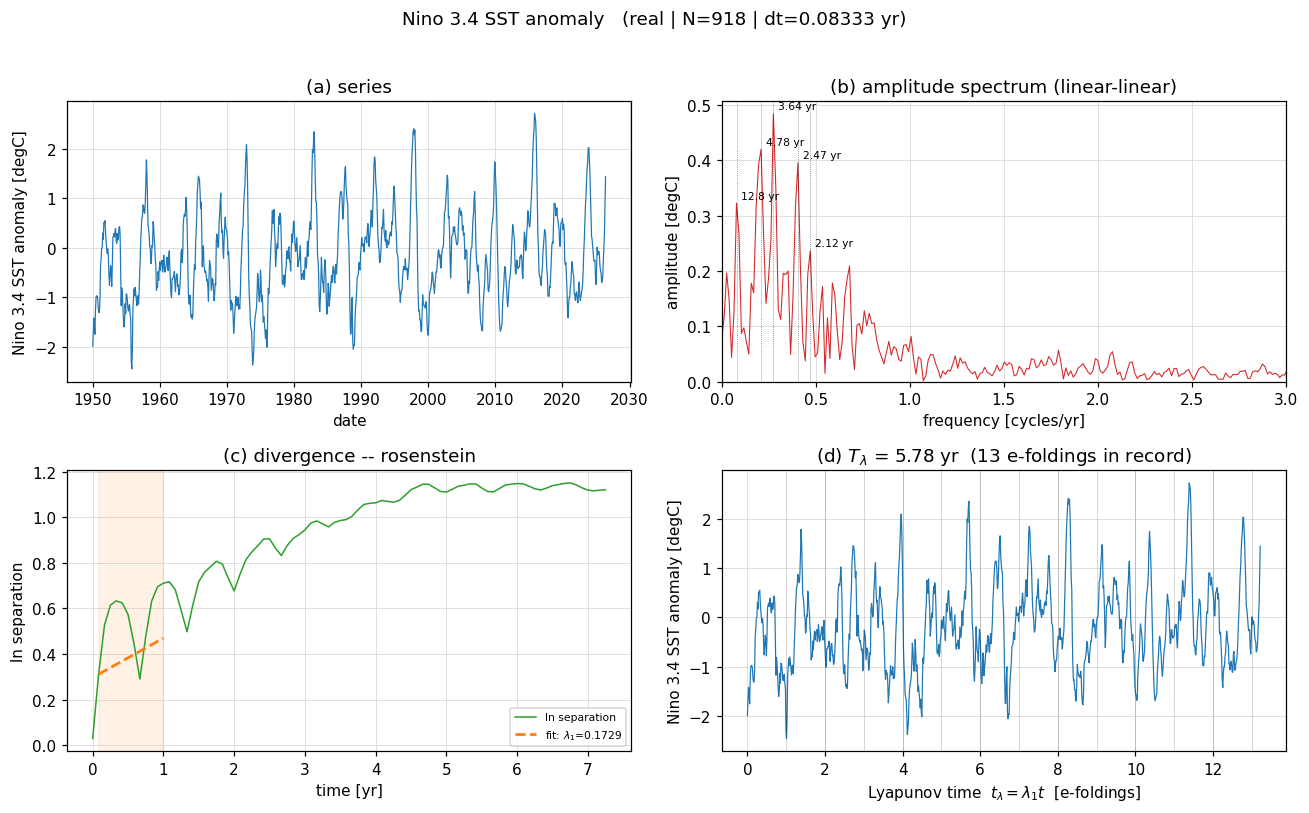


=== Nino 3.4 SST anomaly  [real]
  N = 918   dt = 0.08333 yr   span = 76.5 yr
  lambda_1 = 0.1729 /yr   T_lambda = 5.78 yr   [rosenstein, m=7, tau=8]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 13.2 e-foldings
  dominant periods:
         3.643 yr   (f = 0.27451 /yr,  amp = 0.4834)
         4.781 yr   (f = 0.20915 /yr,  amp = 0.42)
         2.468 yr   (f = 0.40523 /yr,  amp = 0.3955)
         12.75 yr   (f = 0.078431 /yr,  amp = 0.3224)
         2.125 yr   (f = 0.47059 /yr,  amp = 0.2366)


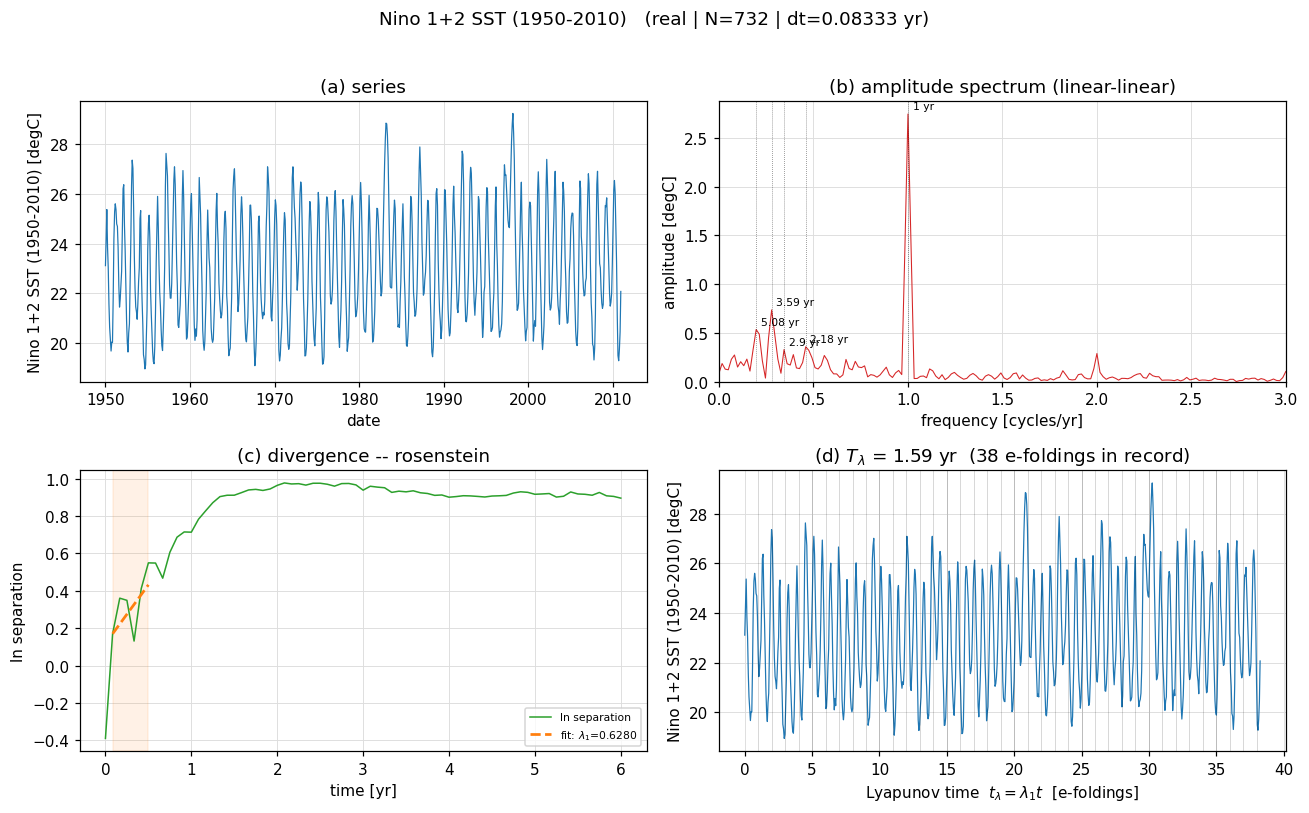


=== Nino 1+2 SST (1950-2010)  [real]
  N = 732   dt = 0.08333 yr   span = 61 yr
  lambda_1 = 0.6280 /yr   T_lambda = 1.59 yr   [rosenstein, m=4, tau=4]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 38.3 e-foldings
  dominant periods:
             1 yr   (f = 1 /yr,  amp = 2.745)
         3.588 yr   (f = 0.27869 /yr,  amp = 0.7365)
         5.083 yr   (f = 0.19672 /yr,  amp = 0.5354)
         2.179 yr   (f = 0.45902 /yr,  amp = 0.3581)
         2.905 yr   (f = 0.34426 /yr,  amp = 0.3293)


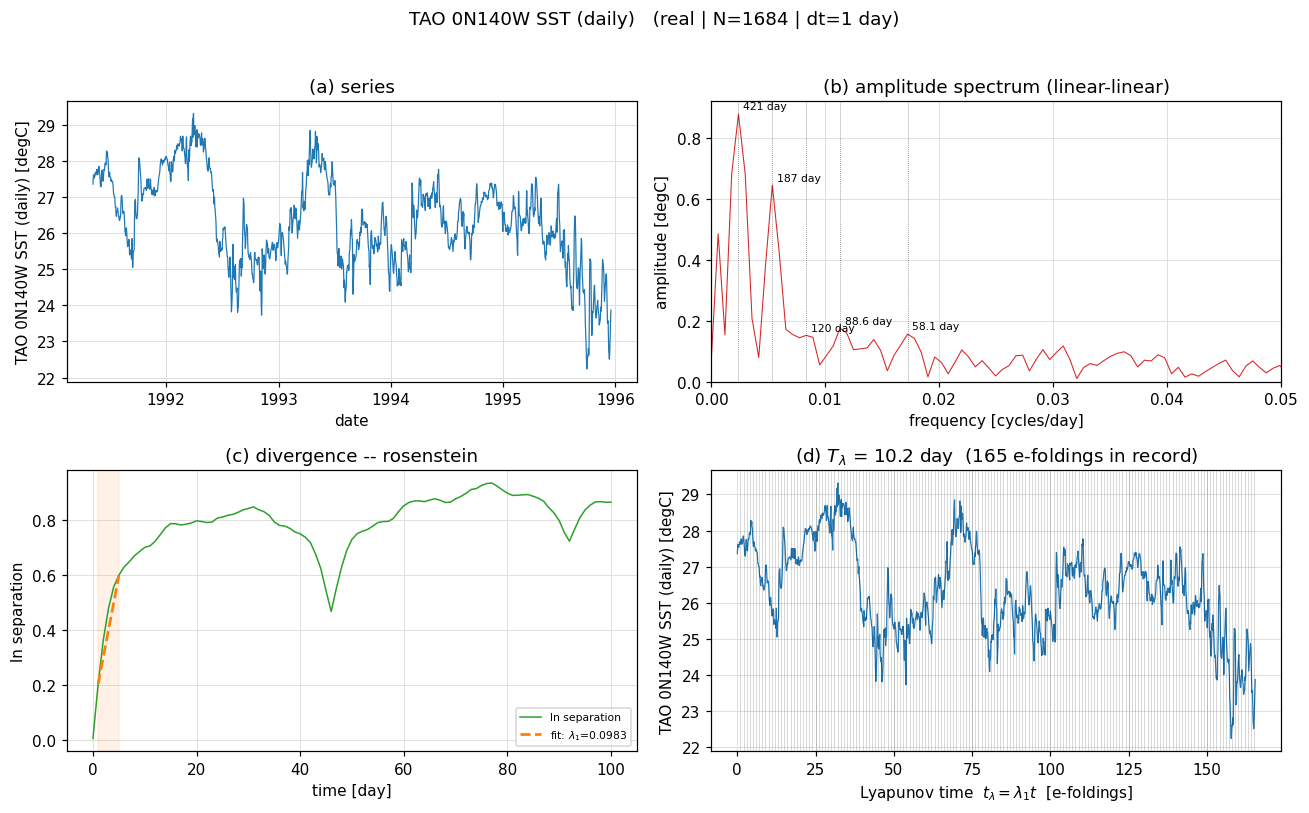


=== TAO 0N140W SST (daily)  [real]
  N = 1684   dt = 1 day   span = 1684 day
  lambda_1 = 0.0983 /day   T_lambda = 10.2 day   [rosenstein, m=5, tau=46]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 165.5 e-foldings
  dominant periods:
           421 day   (f = 0.0023753 /day,  amp = 0.8801)
         187.1 day   (f = 0.0053444 /day,  amp = 0.6465)
         88.63 day   (f = 0.011283 /day,  amp = 0.1762)
         58.07 day   (f = 0.017221 /day,  amp = 0.1566)
         120.3 day   (f = 0.0083135 /day,  amp = 0.1522)


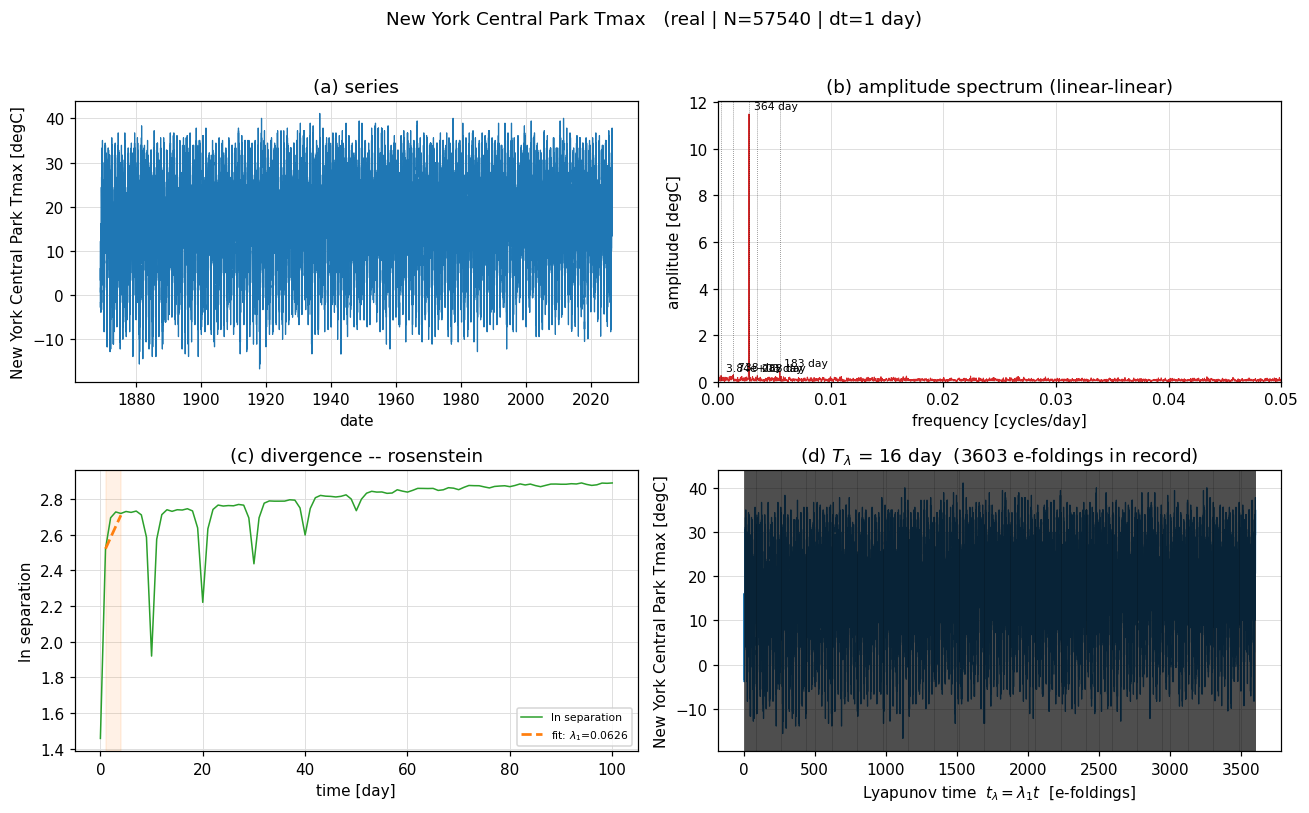


=== New York Central Park Tmax  [real]
  N = 57540   dt = 1 day   span = 5.754e+04 day
  lambda_1 = 0.0626 /day   T_lambda = 16 day   [rosenstein, m=6, tau=10]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 3603.0 e-foldings
  dominant periods:
         364.2 day   (f = 0.0027459 /day,  amp = 11.49)
         182.7 day   (f = 0.0054745 /day,  amp = 0.46)
         737.7 day   (f = 0.0013556 /day,  amp = 0.3003)
          3836 day   (f = 0.00026069 /day,  amp = 0.2652)
         287.7 day   (f = 0.0034758 /day,  amp = 0.2598)


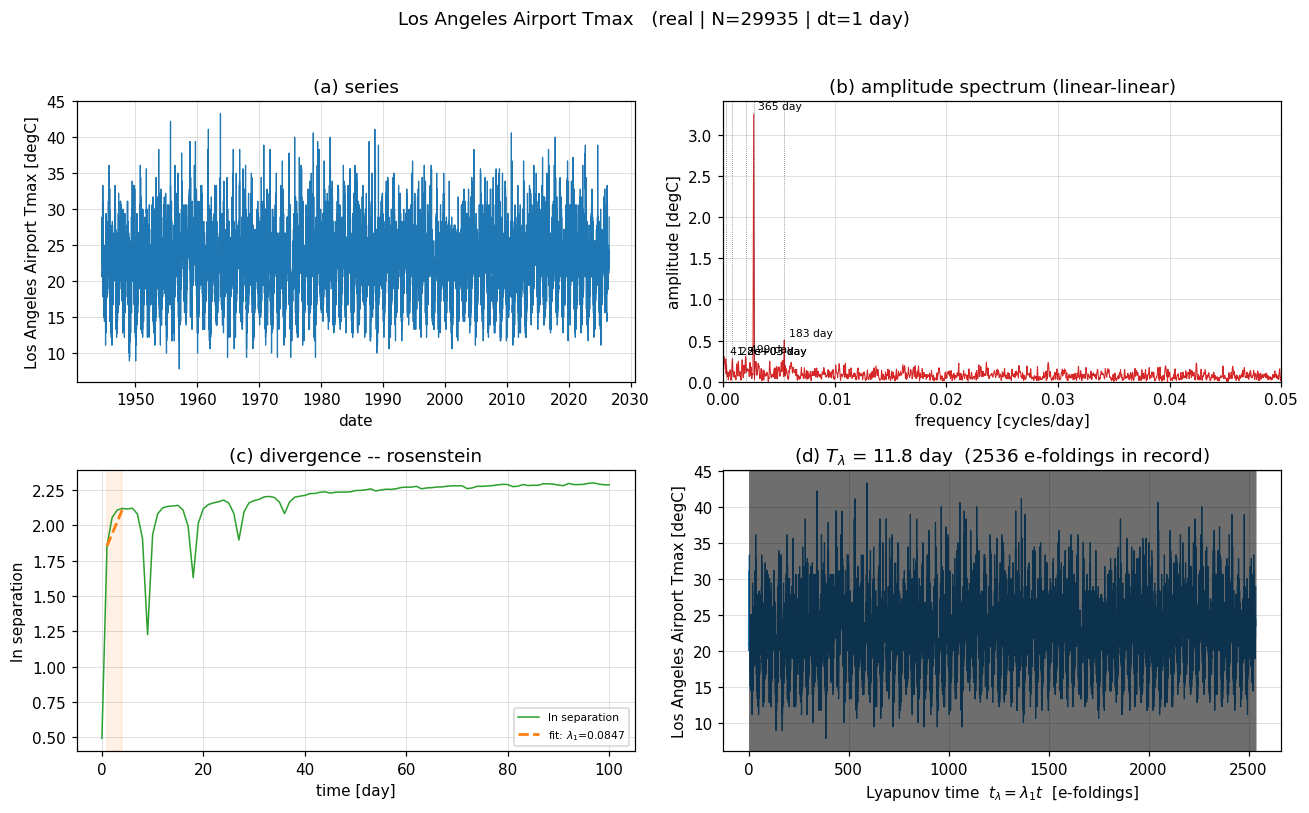


=== Los Angeles Airport Tmax  [real]
  N = 29935   dt = 1 day   span = 2.994e+04 day
  lambda_1 = 0.0847 /day   T_lambda = 11.8 day   [rosenstein, m=5, tau=9]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 2536.2 e-foldings
  dominant periods:
         365.1 day   (f = 0.0027393 /day,  amp = 3.253)
         182.5 day   (f = 0.0054785 /day,  amp = 0.5046)
         498.9 day   (f = 0.0020043 /day,  amp = 0.3084)
          1197 day   (f = 0.00083514 /day,  amp = 0.2784)
          4276 day   (f = 0.00023384 /day,  amp = 0.2756)


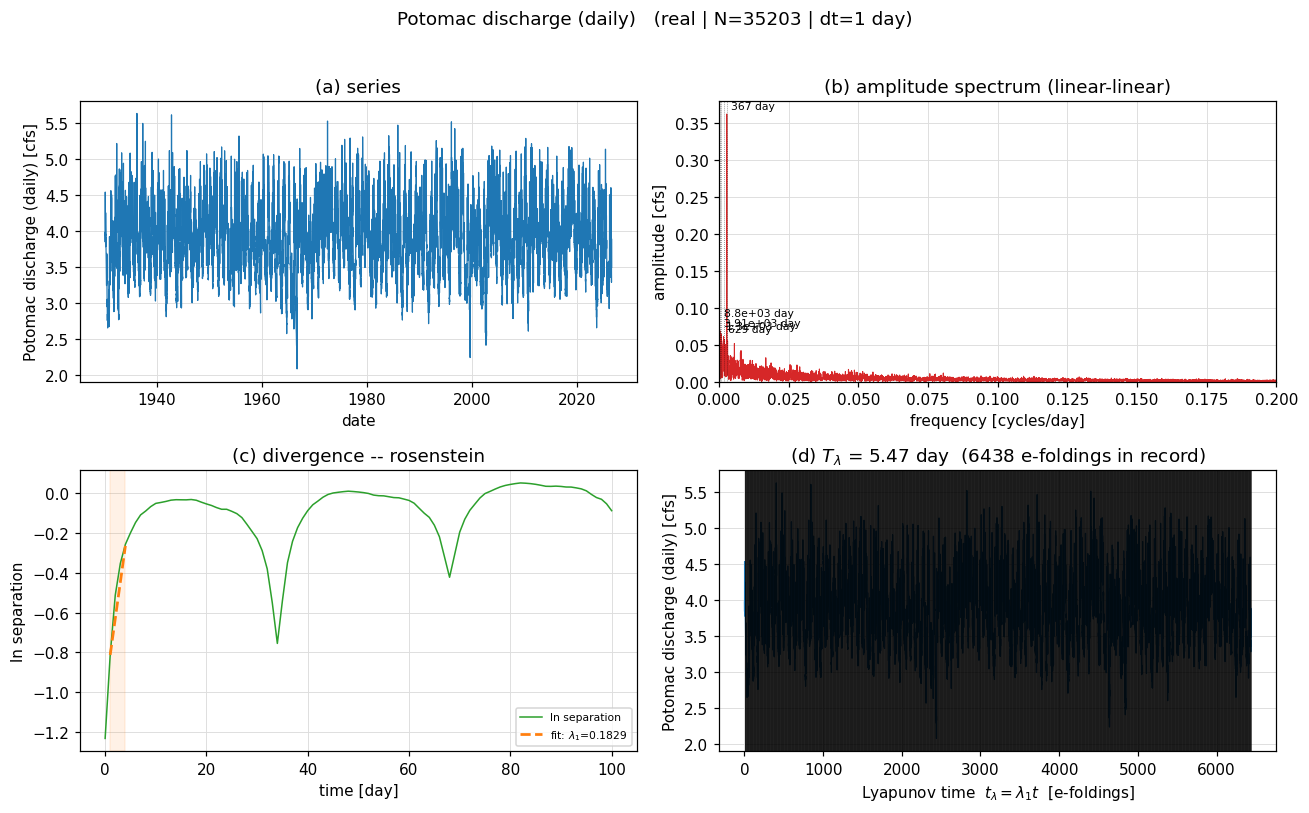


=== Potomac discharge (daily)  [real]
  N = 35203   dt = 1 day   span = 3.52e+04 day
  lambda_1 = 0.1829 /day   T_lambda = 5.47 day   [rosenstein, m=6, tau=34]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 6438.5 e-foldings
  dominant periods:
         366.7 day   (f = 0.002727 /day,  amp = 0.3621)
          8801 day   (f = 0.00011363 /day,  amp = 0.0826)
          3911 day   (f = 0.00025566 /day,  amp = 0.06883)
          1304 day   (f = 0.00076698 /day,  amp = 0.06467)
         628.6 day   (f = 0.0015908 /day,  amp = 0.06085)


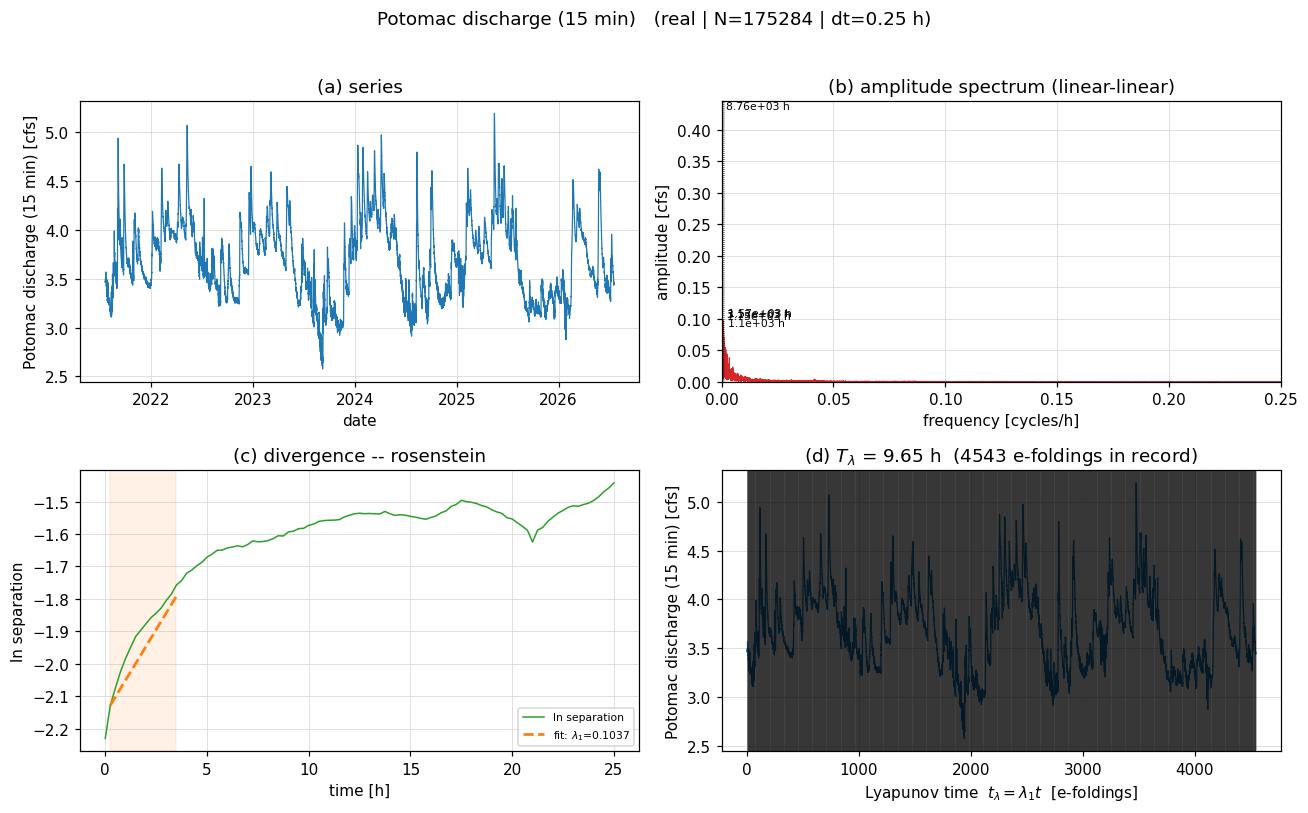


=== Potomac discharge (15 min)  [real]
  N = 175284   dt = 0.25 h   span = 4.382e+04 h
  lambda_1 = 0.1037 /h   T_lambda = 9.65 h   [rosenstein, m=4, tau=84]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 4542.6 e-foldings
  dominant periods:
          8764 h   (f = 0.0001141 /h,  amp = 0.4248)
          1565 h   (f = 0.00063896 /h,  amp = 0.09721)
          3130 h   (f = 0.00031948 /h,  amp = 0.09542)
          1753 h   (f = 0.0005705 /h,  amp = 0.09158)
          1096 h   (f = 0.0009128 /h,  amp = 0.08049)


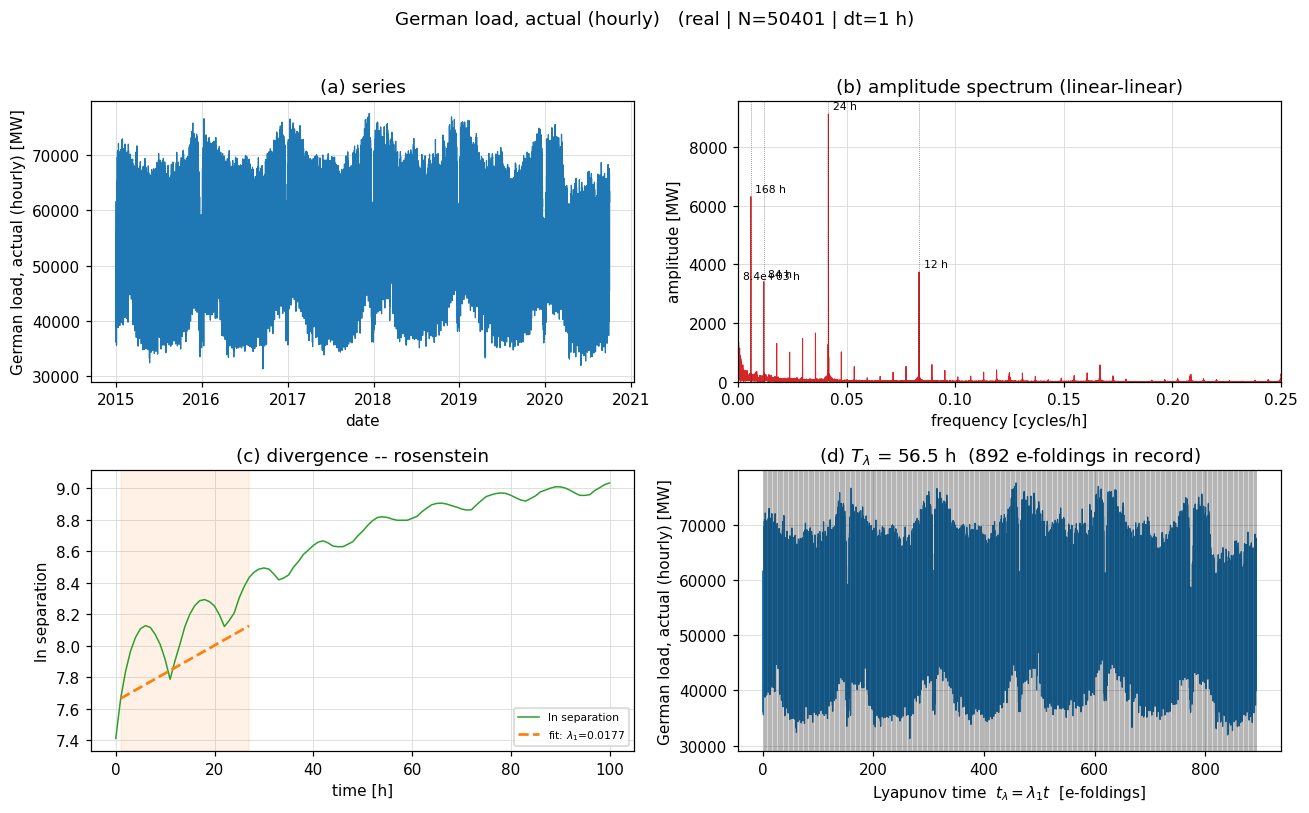


=== German load, actual (hourly)  [real]
  N = 50401   dt = 1 h   span = 5.04e+04 h
  lambda_1 = 0.0177 /h   T_lambda = 56.5 h   [rosenstein, m=5, tau=11]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 892.3 e-foldings
  dominant periods:
            24 h   (f = 0.041666 /h,  amp = 9130)
           168 h   (f = 0.0059523 /h,  amp = 6311)
            12 h   (f = 0.083332 /h,  amp = 3744)
            84 h   (f = 0.011905 /h,  amp = 3412)
          8400 h   (f = 0.00011905 /h,  amp = 3341)


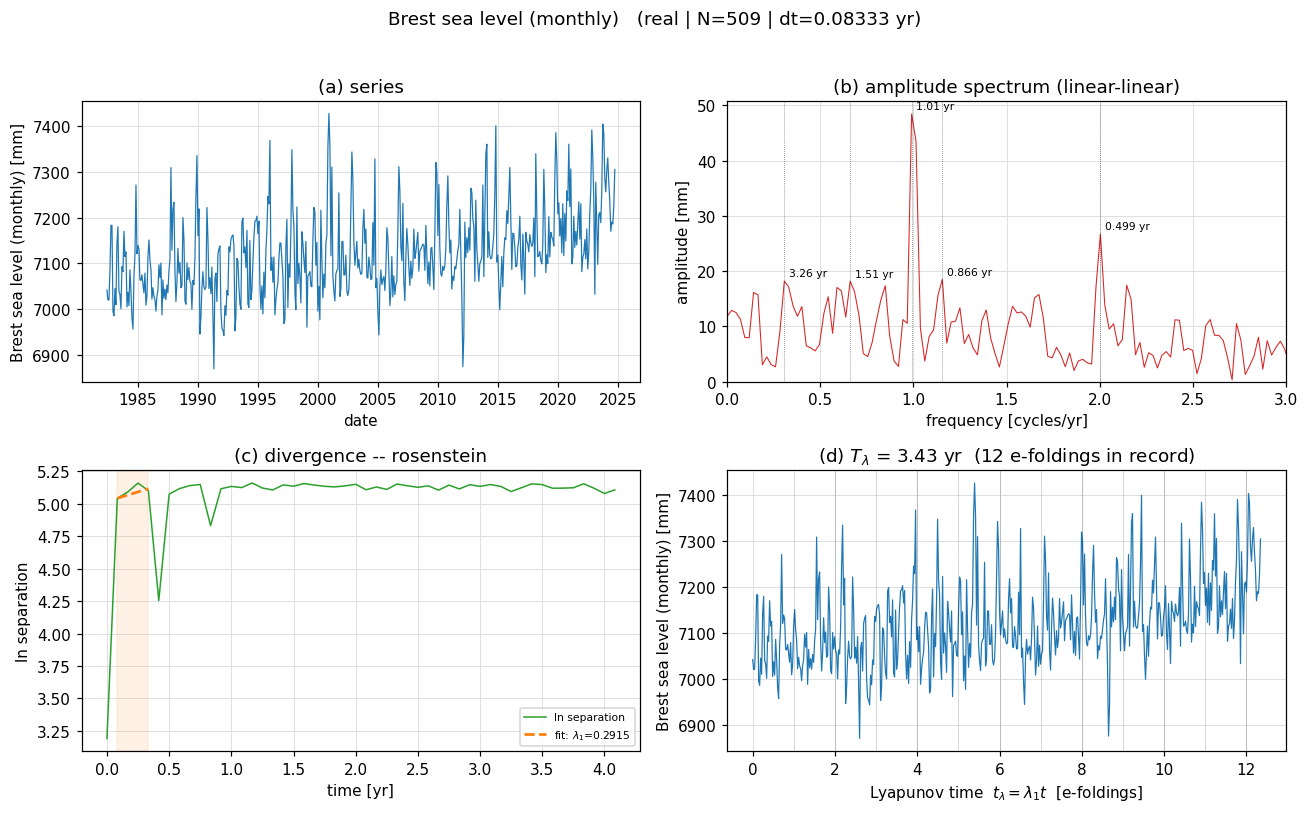


=== Brest sea level (monthly)  [real]
  N = 509   dt = 0.08333 yr   span = 42.42 yr
  lambda_1 = 0.2915 /yr   T_lambda = 3.43 yr   [rosenstein, m=3, tau=5]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 12.4 e-foldings
  dominant periods:
          1.01 yr   (f = 0.99018 /yr,  amp = 48.45)
         0.499 yr   (f = 2.0039 /yr,  amp = 26.72)
        0.8656 yr   (f = 1.1552 /yr,  amp = 18.53)
         3.263 yr   (f = 0.30648 /yr,  amp = 18.22)
         1.515 yr   (f = 0.66012 /yr,  amp = 18.19)


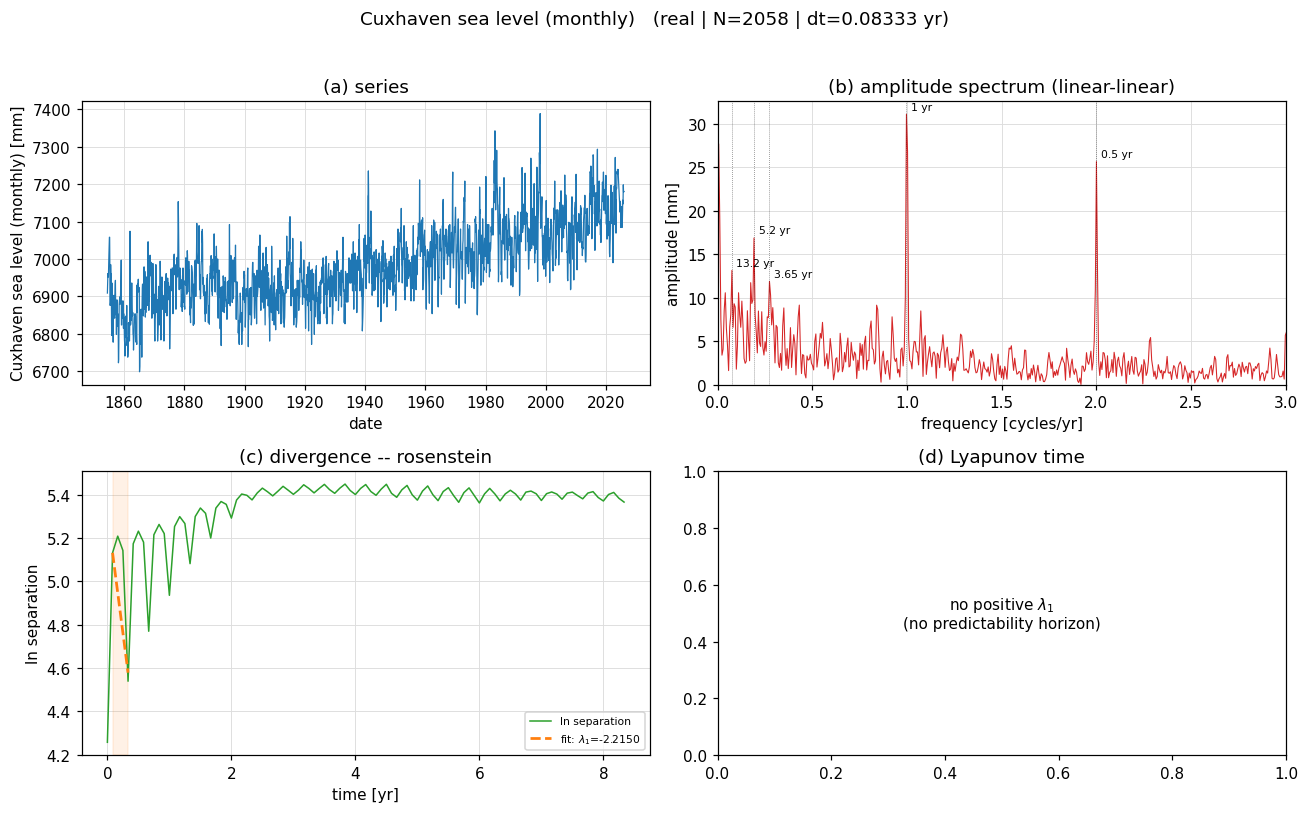


=== Cuxhaven sea level (monthly)  [real]
  N = 2058   dt = 0.08333 yr   span = 171.5 yr
  lambda_1 = -2.2150 /yr   T_lambda = inf yr   [rosenstein, m=7, tau=4]
    single trajectory: upper bound, ~factor-2 uncertainty
  dominant periods:
         1.003 yr   (f = 0.99708 /yr,  amp = 31.08)
           0.5 yr   (f = 2 /yr,  amp = 25.63)
         5.197 yr   (f = 0.19242 /yr,  amp = 16.86)
         13.19 yr   (f = 0.075802 /yr,  amp = 13.13)
         3.649 yr   (f = 0.27405 /yr,  amp = 11.87)


In [3]:
run(tiers.get('real', []))

## 4. Surrogate tier

Generated series, included as controls. λ₁ here describes the generator, not any
physical system.

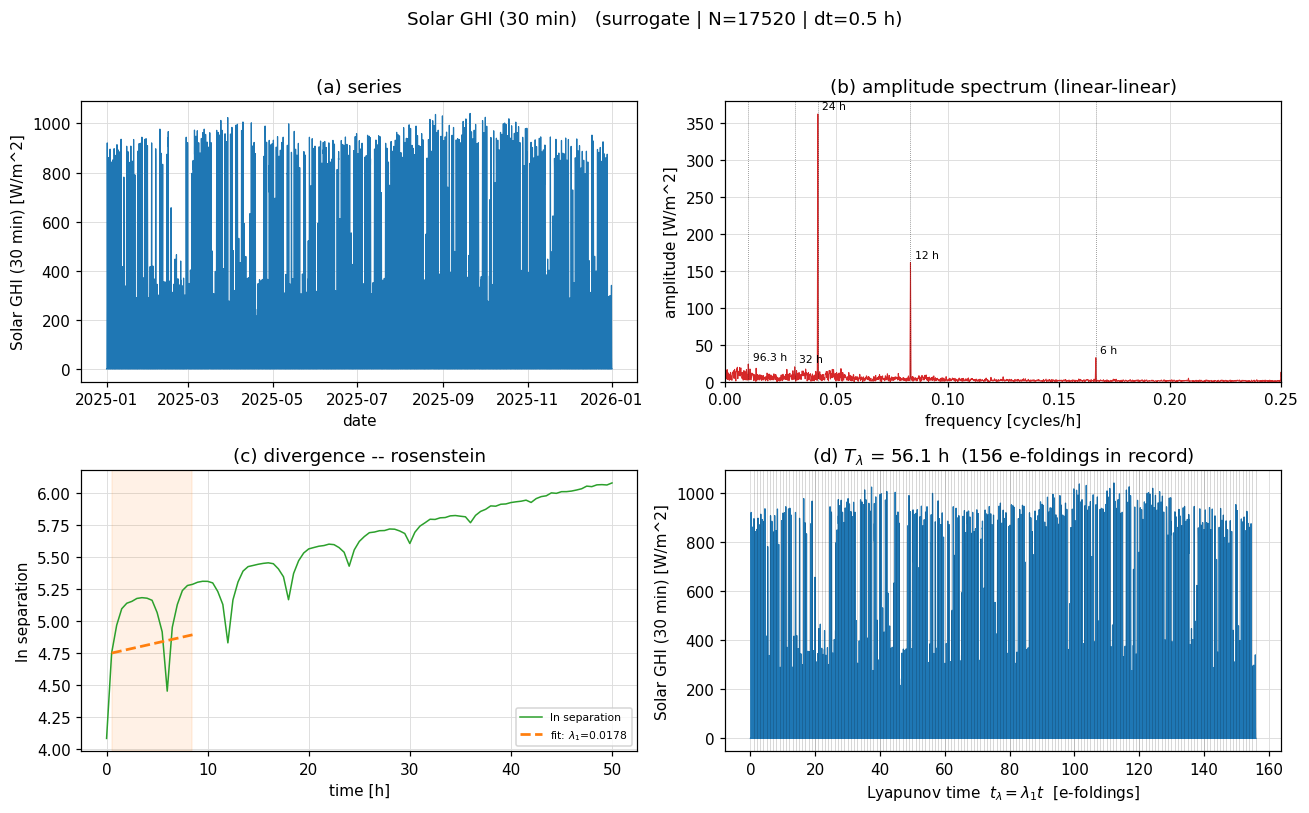


=== Solar GHI (30 min)  [surrogate]
  N = 17520   dt = 0.5 h   span = 8760 h
  lambda_1 = 0.0178 /h   T_lambda = 56.1 h   [rosenstein, m=9, tau=12]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 156.1 e-foldings
  dominant periods:
            24 h   (f = 0.041667 /h,  amp = 361.6)
            12 h   (f = 0.083333 /h,  amp = 161.1)
             6 h   (f = 0.16667 /h,  amp = 32.33)
         96.26 h   (f = 0.010388 /h,  amp = 23.7)
         31.97 h   (f = 0.031279 /h,  amp = 20.05)


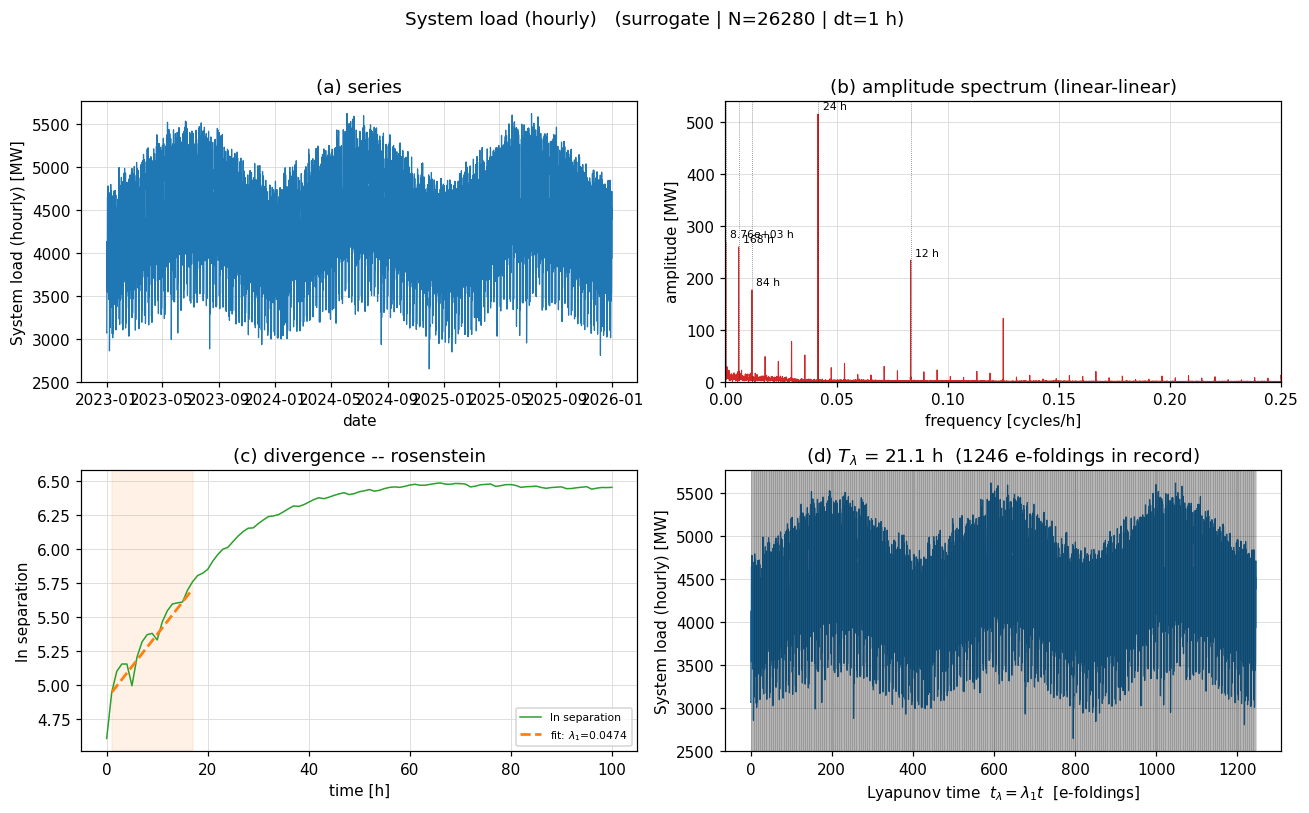


=== System load (hourly)  [surrogate]
  N = 26280   dt = 1 h   span = 2.628e+04 h
  lambda_1 = 0.0474 /h   T_lambda = 21.1 h   [rosenstein, m=5, tau=5]
    single trajectory: upper bound, ~factor-2 uncertainty
  record length = 1245.9 e-foldings
  dominant periods:
            24 h   (f = 0.041667 /h,  amp = 514.9)
          8760 h   (f = 0.00011416 /h,  amp = 268.9)
         168.5 h   (f = 0.0059361 /h,  amp = 259.2)
            12 h   (f = 0.083333 /h,  amp = 233.9)
         83.96 h   (f = 0.01191 /h,  amp = 176.5)


In [4]:
run(tiers.get('surrogate', []))

## 5. Summary

In [5]:
ordered = [k for t in ("chaotic", "real", "surrogate") for k in tiers.get(t, [])]
analysis._table([rows[k] for k in ordered])


dataset          tier         lambda_1     T_lambda      method      err
------------------------------------------------------------------------------
lorenz63         chaotic        0.8231      1.21 natural    ensemble    -9.1%
vallieselnino    chaotic        0.5200      1.92 natural    ensemble    -5.1%
lorenz84         chaotic        0.7499      1.33 natural    ensemble   +62.5%
hadley           chaotic        0.3759      2.66 natural    ensemble   +57.5%
rikitake         chaotic        0.1049      9.54 natural    ensemble   -20.4%
nino34           real           0.1729      5.78 yr  rosenstein         
nino12           real           0.6280      1.59 yr  rosenstein         
tao              real           0.0983      10.2 day  rosenstein         
nyc              real           0.0626        16 day  rosenstein         
lax              real           0.0847      11.8 day  rosenstein         
potomac          real           0.1829      5.47 day  rosenstein         
potomac15      

In [6]:
tbl = pd.DataFrame([{
    "dataset":   k,
    "tier":      rows[k]["tier"],
    "N":         rows[k]["n"],
    "dt":        rows[k]["dt"],
    "unit":      rows[k]["time_unit"],
    "span":      rows[k]["span"],
    "lambda_1":  rows[k]["lyap"],
    "T_lambda":  rows[k]["lyap_time"],
    "e_foldings": rows[k]["e_foldings_in_record"],
    "method":    rows[k]["lyap_method"],
    "truth":     rows[k]["lyap_truth"],
    "error":     rows[k]["lyap_error"],
    "dominant_period": (rows[k]["dominant_periods"][0]["period"]
                        if rows[k]["dominant_periods"] else np.nan),
} for k in ordered]).set_index("dataset")

tbl.round(4)

,tier,N,dt,unit,span,lambda_1,T_lambda,e_foldings,method,truth,error,dominant_period
dataset,,,,,,,,,,,,
lorenz63,chaotic,4000,0.0100,natural,40.0000,0.8231,1.2149,32.9238,ensemble,0.9056,-0.0911,4.4444
vallieselnino,chaotic,2500,0.0221,natural,55.2396,0.5200,1.9231,28.7238,ensemble,0.5478,-0.0507,9.2066
lorenz84,chaotic,2500,0.0626,natural,156.5276,0.7499,1.3334,117.3866,ensemble,0.4615,0.6251,6.2611
hadley,chaotic,2500,0.0145,natural,36.3670,0.3759,2.6601,13.6714,ensemble,0.2387,0.5752,4.0408
rikitake,chaotic,2500,0.0590,natural,147.4965,0.1049,9.5355,15.4682,ensemble,0.1318,-0.2044,7.0236
nino34,real,918,0.0833,yr,76.5000,0.1729,5.7828,13.2289,rosenstein,NaN,NaN,3.6429
nino12,real,732,0.0833,yr,61.0000,0.6280,1.5924,38.3075,rosenstein,NaN,NaN,1.0000
tao,real,1684,1.0000,day,1684.0000,0.0983,10.1751,165.5015,rosenstein,NaN,NaN,421.0000
nyc,real,57540,1.0000,day,57540.0000,0.0626,15.9702,3602.9600,rosenstein,NaN,NaN,364.1772


### Estimator error, chaotic tier only

The single number worth carrying forward: how far the estimator lands from
published λ₁ where published λ₁ exists.

In [7]:
chaotic = tbl[tbl["truth"].notna()]
if len(chaotic):
    err = chaotic["error"].abs()
    display(chaotic[["lambda_1", "truth", "error", "method"]].round(4))
    print(f"\nmean |error| = {err.mean():.1%}   "
          f"range {chaotic['error'].min():+.1%} .. {chaotic['error'].max():+.1%}")

,lambda_1,truth,error,method
dataset,,,,
lorenz63,0.8231,0.9056,-0.0911,ensemble
vallieselnino,0.5200,0.5478,-0.0507,ensemble
lorenz84,0.7499,0.4615,0.6251,ensemble
hadley,0.3759,0.2387,0.5752,ensemble
rikitake,0.1049,0.1318,-0.2044,ensemble



mean |error| = 30.9%   range -20.4% .. +62.5%


## 6. Caveats

- **Rosenstein rows are not ensemble rows.** Only the chaotic tier has
  independent realizations. Everything in sections 3 and 4 substitutes spatial
  nearest neighbours inside one delay embedding for those realizations, which is
  a different estimator with a different error, measured in section 5.
- **Seasonal records inflate.** Any series with a strong annual line lets
  embedded neighbours phase-match, which biases Rosenstein high. Every climate
  record here has one; `nino34` is already an anomaly, the rest are not.
- **Window placement dominates the error.** `fit_growth_window` locates the
  scaling region by fraction of total rise, and that placement moves the answer
  more than the divergence curve itself does. Panel (c) draws the window used,
  so a bad one is visible rather than hidden in a single reported number.
- **`MAX_N` changes the answer,** not just the runtime — it sets how much of the
  record the neighbour search sees. Re-run with the same `MAX_N` when comparing.
